# Etapa 2 — Desagregação espacial do Déficit Habitacional (Random Forest + Escores de Propensão)

## **Metodologia**

Este notebook implementa a **abordagem final** adotada pelo projeto, em duas etapas:

1. **Modelagem (Random Forest):** um modelo de regressão `RandomForestRegressor` é treinado
   nas **Áreas de Ponderação (AP)**, usando 68 variáveis explicativas do questionário do
   universo do Censo para prever o
   **déficit habitacional total** (metodologia FJP).
2. **Desagregação espacial baseada em propensão:** o modelo treinado é aplicado aos
   **Setores Censitários (SC)** — não para prever o déficit em si, mas para gerar um
   **escore de propensão relativa**. Esses escores são normalizados dentro de cada AP e usados
   como pesos para **redistribuir proporcionalmente** o déficit total, já conhecido, da AP entre
   seus setores. Isso garante, por construção, que a soma dos setores sempre bate com o valor
   oficial da AP (ver seção de Auditoria).

Essa escolha resolve o problema identificado na fase exploratória com XGBoost (ver
[`02_AreaDePonderacao_IC.ipynb`](02_AreaDePonderacao_IC.ipynb)), em que prever o déficit
diretamente em cada setor gerava superestimação sistemática ao somar os setores de uma mesma AP.

A qualidade do modelo é avaliada por:
- Métricas de regressão (R², MAE, RMSE) com validação cruzada 5-fold;
- Técnicas de interpretabilidade (**SHAP** e **Permutation Importance**), para identificar quais
  variáveis mais influenciam as predições;
- Auditoria numérica da redistribuição (a soma dos setores deve reproduzir o valor da AP);
- Autocorrelação espacial das estimativas finais (**Índice de Moran Global** e **LISA**), para
  verificar se a distribuição espacial resultante é coerente com o fenômeno urbano estudado.

> Se você não tem familiaridade com algum desses conceitos (Random Forest, SHAP, escores de
> propensão, Índice de Moran), veja o notebook
> [`01_conceitos_teoricos.ipynb`](01_conceitos_teoricos.ipynb), que explica cada técnica com
> exemplos didáticos e pequenas simulações antes de você seguir para os resultados reais abaixo.



In [1]:
import pandas as pd

# 1. Carregar os bancos de dados
df_sp_ap = pd.read_excel('BD_SP_DEFICIT.xlsx')
df_sp_sc = pd.read_excel('BANCO_SP_setorcensitario.xlsx')

### Verificação
Antes de seguir, verificamos a dimensão de cada banco.

In [2]:
print(f"BANCO DE DADOS DE AREA DE PONDERACAO")
print(f"Total de linhas (APs): {len(df_sp_ap)}")

# Visualizar as primeiras linhas
df_sp_ap.head()

BANCO DE DADOS DE AREA DE PONDERACAO
Total de linhas (APs): 1878


,AREA_POND,Cod_UF,Nome_da_UF,Cod_meso,Nome_da_meso,Cod_micro,Nome_da_micro,Cod_RM,Nome_da_RM,Cod_municipio,...,Soma_V206,Soma_V207,Soma_soma_V202eV203,Soma_soma_V204eV205,Soma_soma_V206eV207,DOMICILIOS_PRECARIOS,COABITACAO,ONUS_EXCESSIVO,ADENSAMENTO,DEFICIT_TOTAL
0,3500105003001,35,São Paulo,3508,Presidente Prudente,35035,Adamantina,0,Municípios não pertencentes a estrutura de RM,3500105,...,0,0,3991,17,0,0,164,210,20,394
1,3500105003002,35,São Paulo,3508,Presidente Prudente,35035,Adamantina,0,Municípios não pertencentes a estrutura de RM,3500105,...,0,0,6487,99,0,53,403,226,23,705
2,3500204001001,35,São Paulo,3501,São José do Rio Preto,35004,São José do Rio Preto,0,Municípios não pertencentes a estrutura de RM,3500204,...,0,0,1044,37,0,0,67,40,6,112
3,3500303003001,35,São Paulo,3507,Campinas,35029,Pirassununga,0,Municípios não pertencentes a estrutura de RM,3500303,...,2,2,8644,127,4,34,637,524,104,1300
4,3500402001001,35,São Paulo,3507,Campinas,35030,São João da Boa Vista,0,Municípios não pertencentes a estrutura de RM,3500402,...,0,10,2042,202,10,8,124,96,17,246


In [3]:
print(f"BANCO DE DADOS DE SETORES CENSITARIOS")
print(f"Total de linhas (setores): {len(df_sp_sc)}")

# Visualizar as primeiras linhas
df_sp_sc.head()

BANCO DE DADOS DE SETORES CENSITARIOS
Total de linhas (setores): 60483


,Cod_setor,Cod_Grandes_Regiões,Nome_Grande_Regiao,Cod_UF,Nome_da_UF,Cod_meso,Nome_da_meso,Cod_micro,Nome_da_micro,Cod_RM,...,Domicílios particulares permanentes que não tinham banheiro ou sanitário – Existe lixo acumulado nos logradouros,Domicílios particulares permanentes com moradia adequada – Existe identificação do logradouro,Domicílios particulares permanentes com moradia adequada – Não existe identificação do logradouro,Domicílios particulares permanentes com moradia semi-adequada – Existe identificação do logradouro,Domicílios particulares permanentes com moradia semi-adequada – Não existe identificação do logradouro,Domicílios particulares permanentes com moradia inadequada – Existe identificação do logradouro,Domicílios particulares permanentes com moradia inadequada – Não existe identificação do logradouro,soma_V202eV203,soma_V204eV205,soma_V206eV207
0,355030801000001,3,Região Sudeste,35,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,0,228,5,33,0,0,0,233,33,0
1,355030801000002,3,Região Sudeste,35,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,0,306,0,0,0,0,0,306,0,0
2,355030801000003,3,Região Sudeste,35,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,0,184,0,5,0,0,0,184,5,0
3,355030801000004,3,Região Sudeste,35,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,0,181,0,0,0,0,0,181,0,0
4,355030801000005,3,Região Sudeste,35,São Paulo,3515,Metropolitana de São Paulo,35061,São Paulo,20,...,0,239,0,1,0,0,0,239,1,0


## Configuração das variáveis do modelo

- `FEATURES`: as 68 variáveis explicativas do questionário do universo (colunas 12 a 79 do banco
  de AP), relacionadas a habitação, infraestrutura, composição familiar e renda. A descrição
  completa de cada `Soma_V0XX` está em `docs/DICIONÁRIO VARIÁVEIS.xlsx`.
- `SAIDAS`: os cinco componentes do déficit habitacional (metodologia FJP), presentes apenas no
  banco de AP — é a partir deles que o modelo aprende a relação entre características do
  território e necessidade habitacional.
- `COL_AP_AP` / `COL_AP_SC` / `COL_SC`: colunas-chave usadas para conectar os dois bancos
  (identificador da AP em cada um deles, e identificador do setor censitário).

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [5]:
# Colunas-chave para conectar os bancos de AP e de Setor Censitário
COL_AP_AP = "AREA_POND"          # nome da coluna de AP no banco de AP
COL_AP_SC = "Área de Ponderação"       # nome da coluna de AP no banco de SC
COL_SC = "Cod_setor"       # código do setor censitário



In [6]:
SAIDAS = [
    "DOMICILIOS_PRECARIOS",
    "COABITACAO",
    "ONUS_EXCESSIVO",
    "ADENSAMENTO",
    "DEFICIT_TOTAL"
]

In [7]:
# Criamos a lista de FEATURES selecionando pelo índice das colunas
#(entradas do modelo)
# O intervalo [11:79] pega da coluna 12 até a 79
FEATURES = df_sp_ap.columns[11:79].tolist()

In [8]:
print(f"Total de features utilizadas: {len(FEATURES)}")
print(FEATURES[0], "até", FEATURES[-1])

Total de features utilizadas: 68
Soma_V002.x até Soma_soma_V206eV207


## **Treinamento do modelo Random Forest (nas Áreas de Ponderação)**

Antes de treinar, removemos as APs em que a variável-alvo (`DEFICIT_TOTAL`) está ausente — elas
serão preenchidas com a própria predição do modelo mais adiante (ver seção *Predição para todas
as APs*), mas não podem ser usadas no treino.

O `RandomForestRegressor` foi configurado com 200 árvores (`n_estimators=200`) e
`random_state=42` para reprodutibilidade. Os dados são divididos em 80% treino / 20% teste.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# remover faltantes
df_ap_modelo = df_sp_ap.dropna(subset=["DEFICIT_TOTAL"]).copy()

# Definição de X (Features) e y (Target)
X = df_ap_modelo[FEATURES]
y = df_ap_modelo["DEFICIT_TOTAL"]

# divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# modelo
# Configuração do modelo Random Forest
modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# treino
modelo_rf.fit(X_train, y_train)

# previsão
y_pred = modelo_rf.predict(X_test)

# métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n MÉTRICAS – DEFICIT_TOTAL - RANDOM FOREST  (AP)")
print(f"R²  : {r2:.3f}")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


 MÉTRICAS – DEFICIT_TOTAL - RANDOM FOREST  (AP)
R²  : 0.952
MAE : 97.609
RMSE: 142.696


### **Observado vs. Previsto (conjunto de teste)**

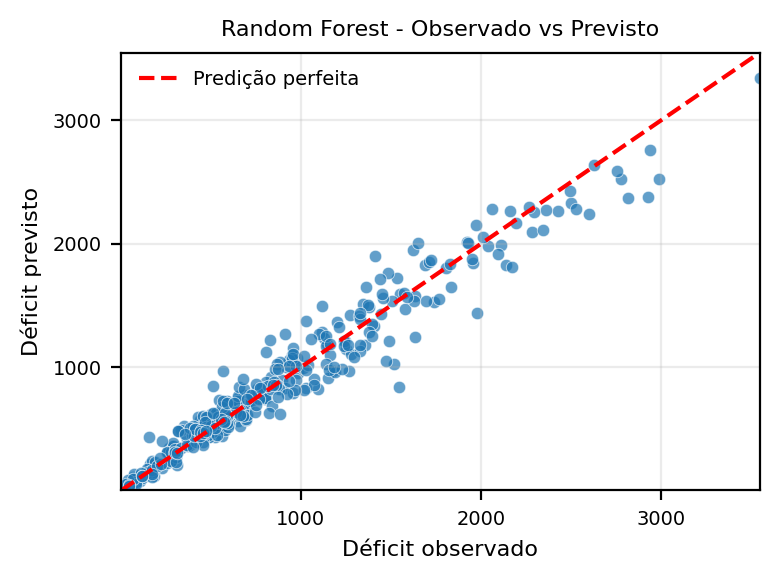

In [10]:
# ==========================================
# OBSERVADO VS PREVISTO
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4, 3), dpi=200)

plt.scatter(
    y_test,
    y_pred,
    s=20,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.3
)

# Limites iguais para os eixos
lim_min = min(y_test.min(), y_pred.min())
lim_max = max(y_test.max(), y_pred.max())

# Linha ideal
plt.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle='--',
    linewidth=1.5,
    color='red',
    label='Predição perfeita'
)

plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)

plt.xlabel('Déficit observado', fontsize=8)
plt.ylabel('Déficit previsto', fontsize=8)
plt.title("Random Forest - Observado vs Previsto", fontsize=8)

# Diminui os números dos eixos
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.grid(True, alpha=0.25)

# Diminui a legenda
plt.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.show()

## **Validação cruzada (5-fold)**

Uma única divisão treino/teste pode ser sensível à sorte do sorteio (quais APs caíram no teste).
Para obter uma medida mais robusta da capacidade de generalização do modelo, aplicamos
**validação cruzada em 5 partições**: o conjunto de dados é dividido em 5 partes; a cada rodada,
4 partes treinam o modelo e 1 parte avalia, alternando qual parte é usada para teste.

In [11]:
# =====================================================
# VALIDAÇÃO CRUZADA (CROSS VALIDATION)
# =====================================================

from sklearn.model_selection import cross_val_score

scores_r2 = cross_val_score(
    modelo_rf,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

scores_mae = -cross_val_score(
    modelo_rf,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print("\n===== VALIDAÇÃO CRUZADA =====")

print("R² por Fold:")
print(scores_r2)

print(f"R² Médio: {scores_r2.mean():.4f}")
print(f"R² Desvio: {scores_r2.std():.4f}")

print(f"MAE Médio: {scores_mae.mean():.4f}")
print(f"MAE Desvio: {scores_mae.std():.4f}")


===== VALIDAÇÃO CRUZADA =====
R² por Fold:
[0.92945357 0.94319551 0.94950391 0.87677297 0.91821408]
R² Médio: 0.9234
R² Desvio: 0.0257
MAE Médio: 104.2461
MAE Desvio: 37.5037


### Interpretação da validação cruzada

Resultados obtidos (relatório final):

| Fold | R² |
|---|---|
| 1 | 0,9295 |
| 2 | 0,9432 |
| 3 | 0,9495 |
| 4 | 0,8768 |
| 5 | 0,9182 |
| **Média** | **0,9234** |
| **Desvio padrão** | **0,0257** |

**MAE médio = 104,25** (desvio padrão 37,50).

A baixa variabilidade do R² entre os folds (desvio padrão de apenas 0,0257 em torno de uma média
de 0,92) indica que o modelo tem **desempenho estável** e não depende de uma divisão específica
dos dados — ou seja, não parece haver overfitting relevante a um subconjunto particular de APs.
Esse resultado dá segurança para usar o modelo na etapa seguinte (geração dos escores de
propensão para os setores censitários).


## **Interpretabilidade — SHAP (SHapley Additive exPlanations)**

Antes de aplicar o modelo aos setores, é importante entender **o que ele aprendeu**: quais
variáveis mais pesam nas predições, e em que direção. Isso é feito com **SHAP**, que atribui a
cada variável, em cada predição individual, uma contribuição (positiva ou negativa) para o valor
final — com base na teoria dos valores de Shapley (jogos cooperativos).

> Se não conhece SHAP em detalhe, veja a explicação didática em
> [`03_conceitos_teoricos.ipynb`](01_conceitos_teoricos.ipynb).

In [12]:
!pip install shap


Calculando SHAP...


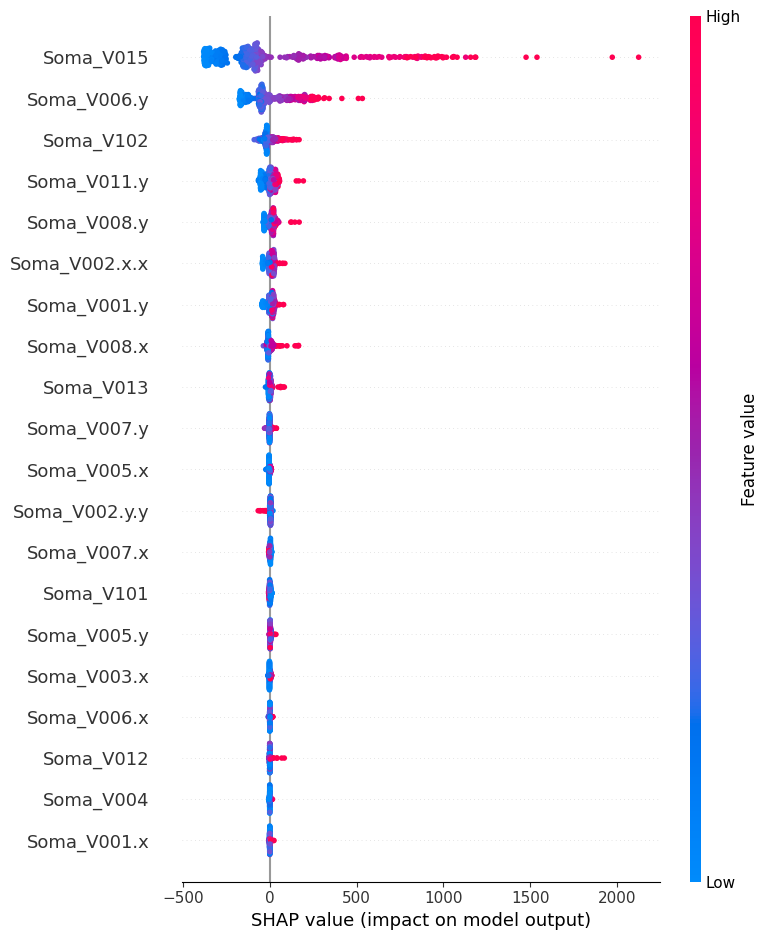

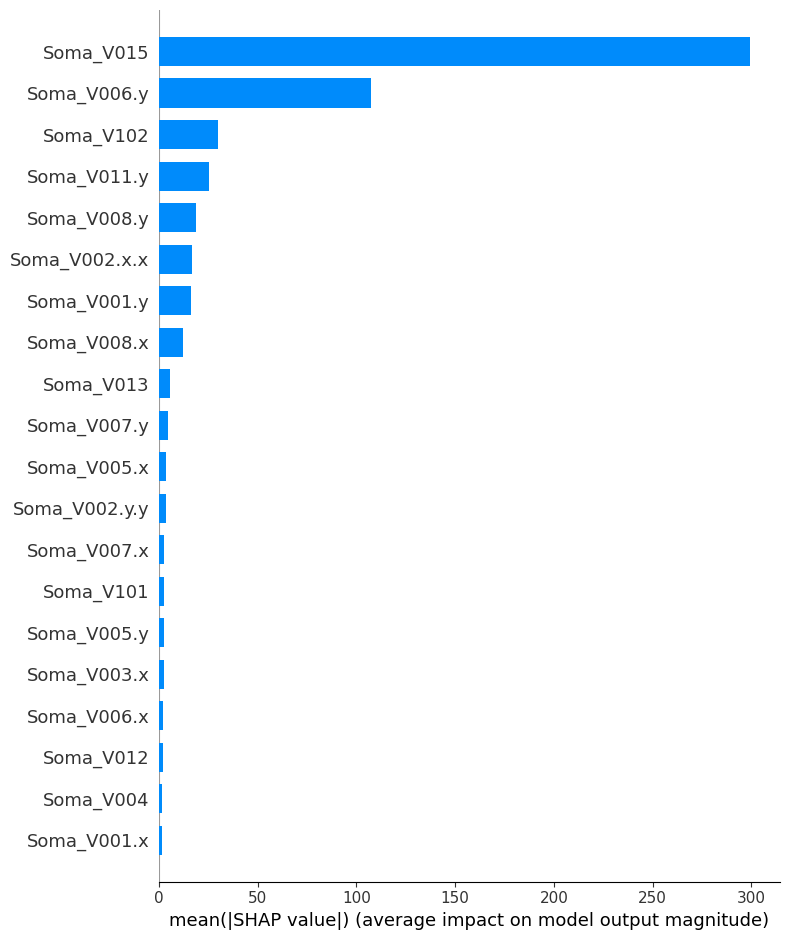

In [13]:
# =====================================================
# SHAP VALUES
# =====================================================

import shap

print("\nCalculando SHAP...")

explainer = shap.TreeExplainer(modelo_rf)

amostra = X.sample(
    min(500, len(X)),
    random_state=42
)

shap_values = explainer.shap_values(amostra)

# Beeswarm
shap.summary_plot(
    shap_values,
    amostra,
    show=True
)

# Ranking médio
shap.summary_plot(
    shap_values,
    amostra,
    plot_type="bar",
    show=True
)

## **Interpretabilidade — Permutation Importance**

Como verificação complementar ao SHAP, calculamos também a **Permutation Importance**: embaralha-
se aleatoriamente os valores de uma variável por vez (quebrando sua relação com o alvo) e mede-se
o quanto o desempenho do modelo (R²) cai. Quanto maior a queda, mais o modelo depende daquela
variável.



===== TOP 20 VARIÁVEIS =====
               Variavel  Importancia
39            Soma_V015     0.503959
30          Soma_V006.y     0.074671
9             Soma_V102     0.021443
13          Soma_V008.x     0.009770
35          Soma_V011.y     0.008738
32          Soma_V008.y     0.005142
20          Soma_V001.y     0.004368
26        Soma_V002.x.x     0.003354
37            Soma_V013     0.002454
31          Soma_V007.y     0.001894
43        Soma_V002.y.y     0.001340
24          Soma_V005.x     0.000955
22          Soma_V003.x     0.000771
12          Soma_V007.x     0.000698
8             Soma_V101     0.000609
36            Soma_V012     0.000605
65  Soma_soma_V202eV203     0.000516
46            Soma_V011     0.000496
6           Soma_V041.x     0.000448
29          Soma_V005.y     0.000439


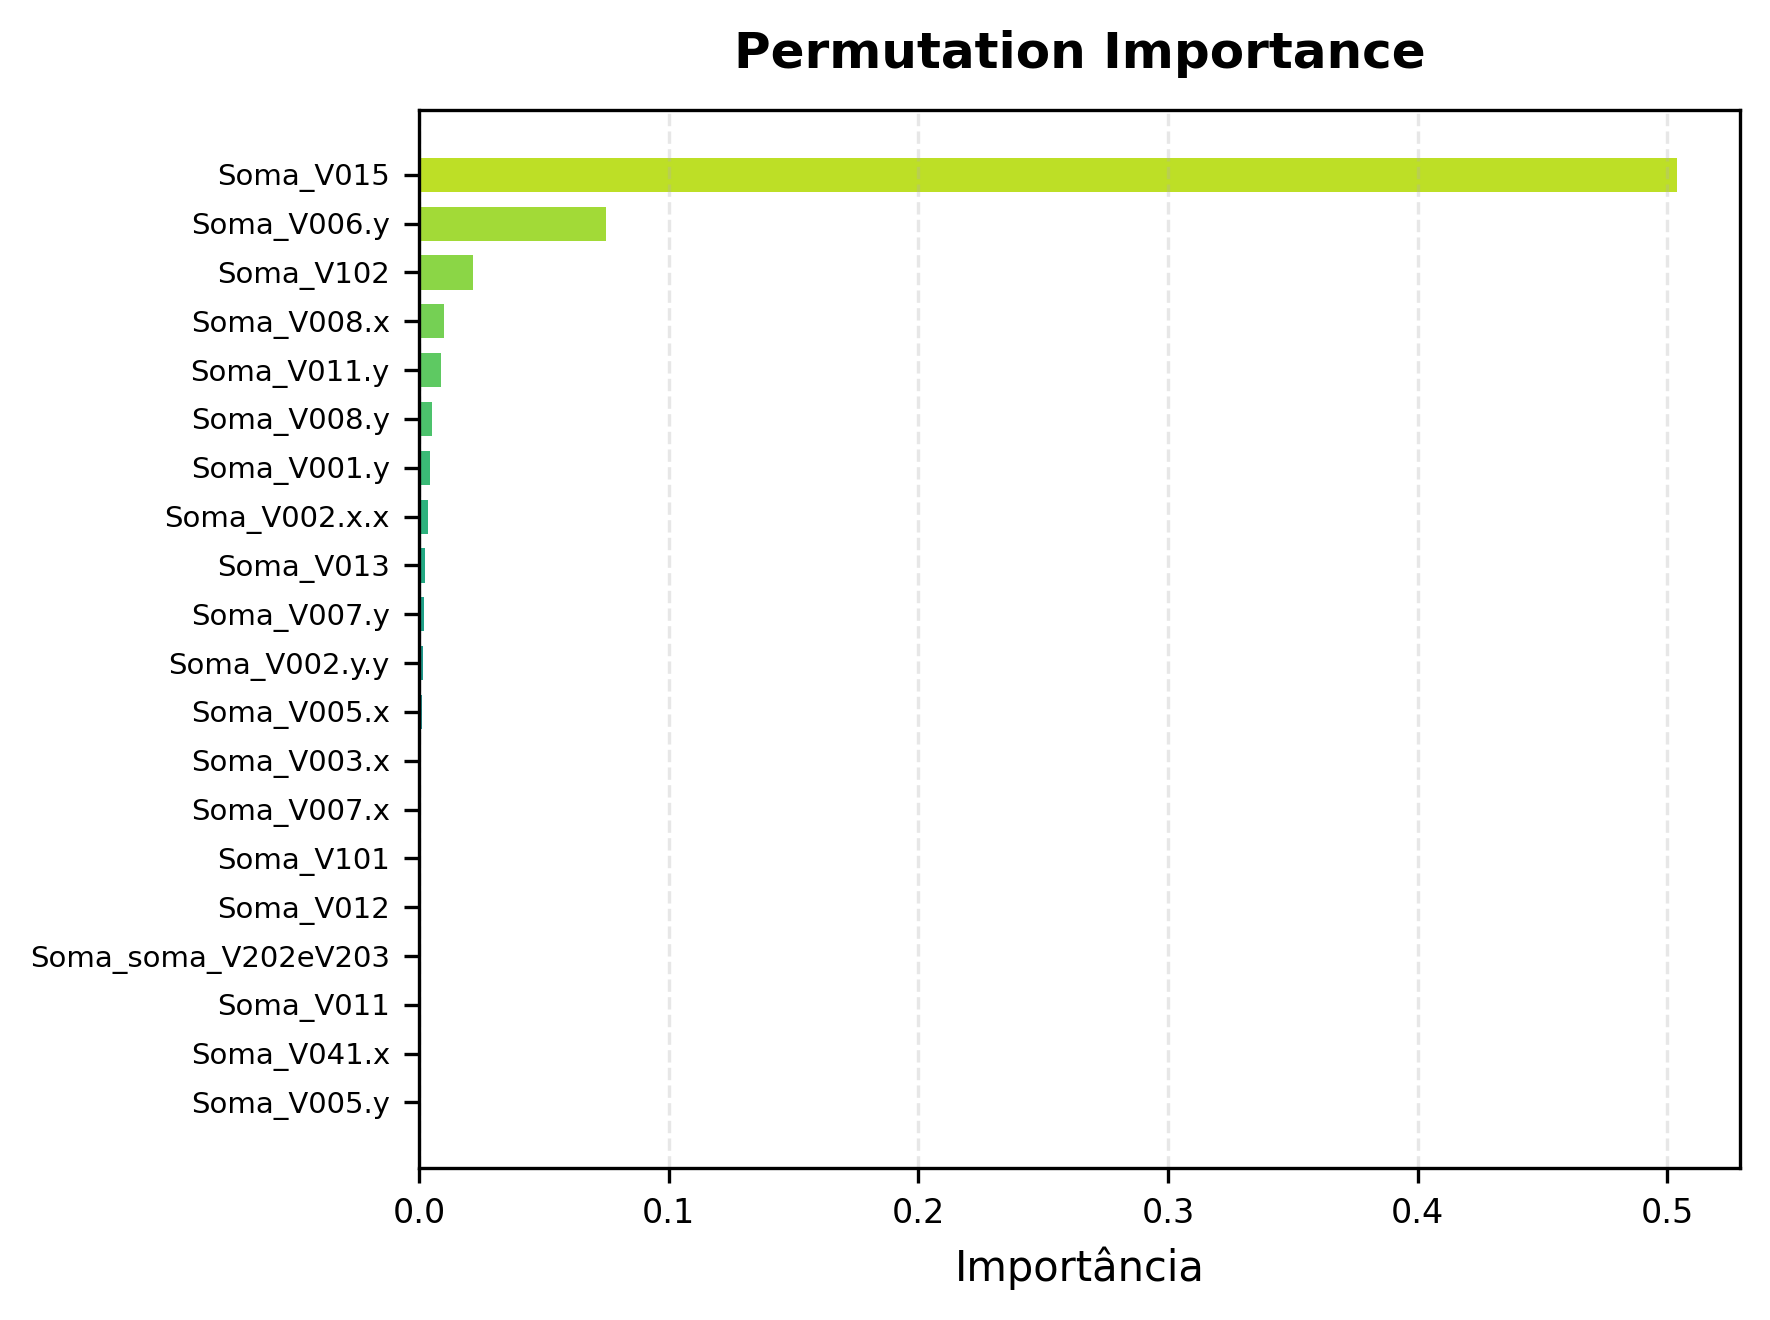

In [14]:
# =====================================================
# PERMUTATION IMPORTANCE
# =====================================================

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

perm = permutation_importance(
    modelo_rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="r2"
)

perm_df = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": perm.importances_mean
})

perm_df = perm_df.sort_values(
    "Importancia",
    ascending=False
)

# Exibe as 20 variáveis mais importantes
print("\n===== TOP 20 VARIÁVEIS =====")
print(perm_df.head(20))

# Dados para o gráfico
top = perm_df.head(20).sort_values("Importancia")

# Paleta viridis
cores = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(top))
)

plt.figure(
    figsize=(6, 4.5),
    dpi=300
)

plt.barh(
    top["Variavel"],
    top["Importancia"],
    color=cores,
    height=0.7
)

plt.title(
    "Permutation Importance",
    fontsize=12,
    fontweight="bold",
    pad=10
)

plt.xlabel(
    "Importância",
    fontsize=10
)

plt.xticks(fontsize=8)
plt.yticks(fontsize=7)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# Salvar em JPG
plt.savefig(
    "Permutation_importance.jpg",
    dpi=300,              # qualidade da imagem
    bbox_inches="tight"   # evita cortes nas bordas
)

plt.show()

---
## **Predição para todas as APs (preenchendo valores faltantes)**

Algumas APs não possuem valor de déficit total calculado pela metodologia FJP (por exemplo, por
limitações amostrais). Para essas APs, usamos a própria predição do modelo como valor de
referência, e criamos uma coluna indicadora (`FONTE_DEFICIT`) para rastrear quais valores são
reais e quais são estimados. Também calculamos o resíduo absoluto do modelo em cada AP, útil como
diagnóstico de confiabilidade.

In [16]:
# Predição para TODAS as APs
df_sp_ap["PRED_AP"] = modelo_rf.predict(df_sp_ap[FEATURES])

# Coluna final
# COL_TARGET = DEFICIT_TOTAL
df_sp_ap["DEFICIT_TOTAL_FINAL"] = df_sp_ap["DEFICIT_TOTAL"]

mask_faltante = df_sp_ap["DEFICIT_TOTAL_FINAL"].isna()

df_sp_ap.loc[mask_faltante, "DEFICIT_TOTAL_FINAL"] = df_sp_ap.loc[
    mask_faltante, "PRED_AP"
]

# Fonte
df_sp_ap["FONTE_DEFICIT"] = "real"
df_sp_ap.loc[mask_faltante, "FONTE_DEFICIT"] = "predito"

# Resíduo (diagnóstico)
# COL_TARGET = DEFICIT_TOTAL
df_sp_ap["RESIDUO_AP"] = np.abs(
    df_sp_ap["DEFICIT_TOTAL"] - df_sp_ap["PRED_AP"]
)

## **Padronização dos nomes das variáveis**
Nesta etapa, é realizado um extenso processo de padronização dos nomes das variáveis do banco de setores censitários.

Essa harmonização é fundamental para garantir compatibilidade com o modelo treinado, já que algoritmos de machine learning exigem consistência entre as variáveis de entrada utilizadas no treinamento e na predição.

In [17]:
df_sc = df_sp_sc.rename(columns={

    "Domicílios particulares permanentes (=DPP)": "Soma_V002.x",

    # banheiro SC E DPS AP
    "Domicílios particulares permanentes sem banheiro de uso exclusivo dos moradores e nem sanitário":
    "Soma_V023.x",
    # lixo
    "Domicílios particulares permanentes com lixo coletado em caçamba de serviço de limpeza":
    "Soma_V037",

    "Domicílios particulares permanentes com lixo queimado na propriedade":
    "Soma_V038",

    "Domicílios particulares permanentes com lixo enterrado na propriedade":
    "Soma_V039",

    "Domicílios particulares permanentes com lixo jogado em terreno baldio oulogradouro":
    "Soma_V040",

    "Domicílios particulares permanentes com lixo jogado em rio, lago ou mar":
    "Soma_V041.x",

    # energia
    "Domicílios particulares permanentes sem energia elétrica":
    "Soma_V046",

    # tipo de casa
    "Domicílios particulares permanentes do tipo casa próprios e em aquisição":
    "Soma_V101",

    "Domicílios particulares permanentes do tipo casa alugados":
    "Soma_V102",

    "Domicílios particulares permanentes do tipo casa cedidos por empregador":
    "Soma_V103",

    "Domicílios particulares permanentes com outra forma de destino do lixo e outra forma de abastecimento de água":
    "Soma_V233",

    # moradores
    "Moradores em domicílios particulares permanentes próprios e em aquisição":
    "Soma_V007.x",

    "Moradores em domicílios particulares permanentes alugados":
    "Soma_V008.x",

    "Moradores em domicílios particulares permanentes cedidos por empregador":
    "Soma_V009.x",

    "Moradores em domicílios particulares permanentes com outra condição de ocupação (não são próprios, alugados, nem cedidos)":
    "Soma_V011.x",

    "Moradores em domicílios particulares permanentes sem banheiro de uso exclusivo dos moradores e nem sanitário":
    "Soma_V023.y",

    "Moradores em domicílios particulares permanentes sem energia elétrica":
    "Soma_V041.y",

    # Pessoas
    "Pessoas responsáveis, do sexo feminino": "Soma_V001.x",
    "Pessoas responsáveis, do sexo masculino": "Soma_V109",

    "Pessoas Residentes":"Soma_V001.y",
    "Pessoas Residentes e cor ou raça - branca":"Soma_V002.y",
    "Pessoas Residentes e cor ou raça - preta":"Soma_V003.x",
    "Pessoas Residentes e cor ou raça - amarela":"Soma_V004.x",
    "Pessoas Residentes e cor ou raça - parda":"Soma_V005.x",
    "Pessoas Residentes e cor ou raça - indígena":"Soma_V006.x",
    "Pessoas residentes em domicílios particulares permanentes":"Soma_V002.x.x",


    "Responsáveis pelos domicílios particulares": "Soma_V003.y",


    "Cônjuges ou companheiros(as) (de sexo diferente e do mesmo sexo da pessoa responsável) em domicílios particulares": "Soma_V004.y",
    "Filhos(as) do responsável e do cônjuge em domicílios particulares": "Soma_V005.y",
    "Filhos(as) somente do responsável em domicílios particulares": "Soma_V006.y",
    "Enteados(as) em domicílios particulares": "Soma_V007.y",
    "Genros ou noras em domicílios particulares": "Soma_V008.y",
    "Pais, mães, padrastos ou madrastas em domicílios particulares": "Soma_V009.y",
    "Sogros (as) em domicílios particulares": "Soma_V010",
    "Netos(as) em domicílios particulares": "Soma_V011.y",
    "Bisnetos(as) em domicílios particulares": "Soma_V012",
    "Irmãos ou irmãs em domicílios particulares": "Soma_V013",
    "Avôs ou avós em domicílios particulares": "Soma_V014.x",
    "Outros parentes em domicílios particulares": "Soma_V015",
    "Agregados(as) em domicílios particulares": "Soma_V016",
    "Conviventes em domicílios particulares": "Soma_V017.x",

    "Total de domicílios particulares improvisados": "Soma_V001",
    "Total do rendimento nominal mensal dos domicílios particulares": "Soma_V002.y.y",
    "Total do rendimento nominal mensal dos domicílios particulares improvisados": "Soma_V004",

    "Domicílios particulares sem rendimento nominal mensal domiciliar per capita": "Soma_V014.y",
    "Domicílios particulares permanentes alugados – Não existe iluminação pública": "Soma_V011",
    "Domicílios particulares permanentes alugados – Não existe pavimentação": "Soma_V017.y",
    "Domicílios particulares permanentes próprios – Existe esgoto a céu aberto": "Soma_V050",
    "Domicílios particulares permanentes alugados – Existe esgoto a céu aberto": "Soma_V052",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe iluminação pública":
    "Soma_V113",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe pavimentação":
    "Soma_V119",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe calçada":
    "Soma_V125",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe meio-fio/guia":
    "Soma_V131",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe bueiro/boca-de-lobo":
    "Soma_V137",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe rampa para cadeirante":
    "Soma_V143",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Não existe arborização":
    "Soma_V149",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Existe esgoto a céu aberto":
    "Soma_V154",

    "Domicílios particulares permanentes que não tinham banheiro ou sanitário – Existe lixo acumulado nos logradouros":
    "Soma_V160",

    "Domicílios particulares permanentes com moradia adequada – Existe identificação do logradouro":
    "Soma_V202",

    "Domicílios particulares permanentes com moradia adequada – Não existe identificação do logradouro":
    "Soma_V203",
    "Domicílios particulares permanentes com moradia semi-adequada – Existe identificação do logradouro": "Soma_V204",
    "Domicílios particulares permanentes com moradia semi-adequada – Não existe identificação do logradouro": "Soma_V205",
    "Domicílios particulares permanentes com moradia inadequada –  Existe identificação do logradouro": "Soma_V206",
    "Domicílios particulares permanentes com moradia inadequada – Não existe identificação do logradouro": "Soma_V207",

    "soma_V202eV203": "Soma_soma_V202eV203",
    "soma_V204eV205": "Soma_soma_V204eV205",
    "soma_V206eV207": "Soma_soma_V206eV207"


})

## **Predição bruta nos Setores Censitários (escores de propensão)**

O modelo Random Forest, treinado nas APs, é aplicado agora **diretamente** aos setores
censitários. É essencial destacar: **esse valor (`PRED_SC_BRUTO`) não é o déficit final do
setor** — é apenas uma medida relativa da propensão de cada setor a apresentar déficit
habitacional, dadas as suas características. Ele só ganha significado quando comparado aos
demais setores da mesma AP (próxima seção).

In [18]:
df_sc["PRED_SC_BRUTO"] = modelo_rf.predict(df_sc[FEATURES])

### **Verificação de consistência das colunas**

Checagem simples, mas importante: confirmar que os dois bancos (AP e SC) realmente compartilham
o mesmo conjunto de nomes de colunas usados como `FEATURES`, evitando erros silenciosos de
predição com colunas fora de ordem ou ausentes.

In [19]:
print("Colunas do banco de AP:")
print(df_sp_ap.columns.tolist())

Colunas do banco de AP:
['AREA_POND', 'Cod_UF', 'Nome_da_UF', 'Cod_meso', 'Nome_da_meso', 'Cod_micro', 'Nome_da_micro', 'Cod_RM', 'Nome_da_RM', 'Cod_municipio', 'Nome_do_municipio', 'Soma_V002.x', 'Soma_V023.x', 'Soma_V037', 'Soma_V038', 'Soma_V039', 'Soma_V040', 'Soma_V041.x', 'Soma_V046', 'Soma_V101', 'Soma_V102', 'Soma_V103', 'Soma_V233', 'Soma_V007.x', 'Soma_V008.x', 'Soma_V009.x', 'Soma_V011.x', 'Soma_V023.y', 'Soma_V041.y', 'Soma_V001.x', 'Soma_V109', 'Soma_V001.y', 'Soma_V002.y', 'Soma_V003.x', 'Soma_V004.x', 'Soma_V005.x', 'Soma_V006.x', 'Soma_V002.x.x', 'Soma_V003.y', 'Soma_V004.y', 'Soma_V005.y', 'Soma_V006.y', 'Soma_V007.y', 'Soma_V008.y', 'Soma_V009.y', 'Soma_V010', 'Soma_V011.y', 'Soma_V012', 'Soma_V013', 'Soma_V014.x', 'Soma_V015', 'Soma_V016', 'Soma_V017.x', 'Soma_V001', 'Soma_V002.y.y', 'Soma_V004', 'Soma_V014.y', 'Soma_V011', 'Soma_V017.y', 'Soma_V050', 'Soma_V052', 'Soma_V113', 'Soma_V119', 'Soma_V125', 'Soma_V131', 'Soma_V137', 'Soma_V143', 'Soma_V149', 'Soma_V154', 

In [21]:
print("Colunas do banco de SC (após padronização):")
print(df_sc.columns.tolist())


Colunas do banco de SC (após padronização):
['Cod_setor', 'Cod_Grandes_Regiões', 'Nome_Grande_Regiao', 'Cod_UF', 'Nome_da_UF', 'Cod_meso', 'Nome_da_meso', 'Cod_micro', 'Nome_da_micro', 'Cod_RM', 'Nome_da_RM', 'Cod_municipio', 'Nome_do_municipio', 'Situacao_setor', 'Área de Ponderação', 'Soma_V002.x', 'Soma_V023.x', 'Soma_V037', 'Soma_V038', 'Soma_V039', 'Soma_V040', 'Soma_V041.x', 'Soma_V046', 'Soma_V101', 'Soma_V102', 'Soma_V103', 'Soma_V233', 'Soma_V007.x', 'Soma_V008.x', 'Soma_V009.x', 'Soma_V011.x', 'Soma_V023.y', 'Soma_V041.y', 'Soma_V001.x', 'Soma_V109', 'Soma_V001.y', 'Soma_V002.y', 'Soma_V003.x', 'Soma_V004.x', 'Soma_V005.x', 'Soma_V006.x', 'Soma_V002.x.x', 'Soma_V003.y', 'Soma_V004.y', 'Soma_V005.y', 'Soma_V006.y', 'Soma_V007.y', 'Soma_V008.y', 'Soma_V009.y', 'Soma_V010', 'Soma_V011.y', 'Soma_V012', 'Soma_V013', 'Soma_V014.x', 'Soma_V015', 'Soma_V016', 'Soma_V017.x', 'Soma_V001', 'Soma_V002.y.y', 'Soma_V004', 'Soma_V014.y', 'Soma_V011', 'Soma_V017.y', 'Soma_V050', 'Soma_V052',

## **Desagregação espacial baseada em escores de propensão**

Esta é a etapa central da metodologia. Para cada Área de Ponderação:

1. Agrupam-se todos os setores censitários pertencentes a ela;
2. Soma-se o escore de propensão bruto (`PRED_SC_BRUTO`) de todos esses setores;
3. Cada setor recebe um **peso relativo**, igual à sua propensão dividida pela soma da AP:

$$P_i = \frac{S_i}{\sum_j S_j}$$

4. O déficit total da AP (`DEFICIT_TOTAL_FINAL`) é então **redistribuído** proporcionalmente
   entre os setores, segundo esse peso:

$$D_i = P_i \times D_{AP}$$

Esse método — conhecido como alocação proporcional baseada em escores de propensão — transforma
um valor conhecido apenas em escala agregada (AP) em uma estimativa espacialmente detalhada
(setor), **sem alterar o total conhecido da AP**: a soma dos $D_i$ de uma AP sempre será
exatamente igual a $D_{AP}$ (ver auditoria logo abaixo).

In [22]:
resultados = []

for cod_ap, grupo_sc in df_sc.groupby(COL_AP_SC):

    linha_ap = df_sp_ap[df_sp_ap[COL_AP_AP] == cod_ap]

    if linha_ap.empty:
        continue

    linha_ap = linha_ap.iloc[0]

    valor_base = linha_ap["DEFICIT_TOTAL_FINAL"]
    fonte = linha_ap["FONTE_DEFICIT"]
    residuo = linha_ap["RESIDUO_AP"]

    soma_pred = grupo_sc["PRED_SC_BRUTO"].sum()

    for _, row in grupo_sc.iterrows():

        if soma_pred > 0:
            peso = row["PRED_SC_BRUTO"] / soma_pred
            deficit_sc = valor_base * peso
        else:
            peso = 0
            deficit_sc = 0

        resultados.append({
            "COD_SC": row[COL_SC],
            "COD_AP": cod_ap,
            "DEFICIT_TOTAL_PROPENSO": deficit_sc,
            "PESO": peso,
            "FONTE_VALOR_AP": fonte,
            "RESIDUO_AP": residuo
        })

In [23]:
df_resultado = (
    pd.DataFrame(resultados)
    .sort_values(["COD_AP", "COD_SC"])
    .reset_index(drop=True)
)

print(df_resultado.head())

            COD_SC         COD_AP  DEFICIT_TOTAL_PROPENSO      PESO  \
0  350010505000009  3500105003001               16.172729  0.041048   
1  350010505000010  3500105003001               18.892467  0.047950   
2  350010505000011  3500105003001               25.621170  0.065028   
3  350010505000012  3500105003001               17.625317  0.044734   
4  350010505000013  3500105003001               14.883503  0.037775   

  FONTE_VALOR_AP  RESIDUO_AP  
0           real      13.915  
1           real      13.915  
2           real      13.915  
3           real      13.915  
4           real      13.915  


## **Auditoria da redistribuição espacial**

Verificação matemática essencial: a soma dos valores redistribuídos para os setores de cada AP
deve reproduzir **exatamente** o valor original da AP. Calculamos a diferença entre a soma dos
setores e o valor da AP, para todas as APs.

In [24]:
auditoria = (
    df_resultado
    .groupby("COD_AP", as_index=False)
    .agg(SOMA_SC=("DEFICIT_TOTAL_PROPENSO", "sum"))
    .merge(
        df_sp_ap[[COL_AP_AP, "DEFICIT_TOTAL_FINAL"]],
        left_on="COD_AP",
        right_on=COL_AP_AP,
        how="left"
    )
)

auditoria["DIFERENCA"] = auditoria["SOMA_SC"] - auditoria["DEFICIT_TOTAL_FINAL"]
auditoria["DIF_ABS"] = auditoria["DIFERENCA"].abs()

print(auditoria.sort_values("DIF_ABS", ascending=False).head())

             COD_AP  SOMA_SC      AREA_POND  DEFICIT_TOTAL_FINAL  \
1274  3548500005007   4401.0  3548500005007                 4401   
1407  3550308005033   2787.0  3550308005033                 2787   
547   3518800005027   2753.0  3518800005027                 2753   
1744  3552205005019   1173.0  3552205005019                 1173   
510   3518701005005   1315.0  3518701005005                 1315   

         DIFERENCA       DIF_ABS  
1274  9.094947e-13  9.094947e-13  
1407 -9.094947e-13  9.094947e-13  
547   4.547474e-13  4.547474e-13  
1744  4.547474e-13  4.547474e-13  
510  -4.547474e-13  4.547474e-13  


### **Interpretação da auditoria**

As maiores diferenças observadas ficam na ordem de **10⁻¹³** — ou seja, compatíveis com erro de
arredondamento de ponto flutuante (o menor erro que um computador consegue representar em cálculos
com números decimais), e não com uma falha real da metodologia. Isso confirma que a desagregação
**preserva integralmente os totais conhecidos das Áreas de Ponderação**: por construção, não há
perda nem criação de déficit no processo, apenas redistribuição.


In [25]:
print(df_resultado.columns)

Index(['COD_SC', 'COD_AP', 'DEFICIT_TOTAL_PROPENSO', 'PESO', 'FONTE_VALOR_AP',
       'RESIDUO_AP'],
      dtype='object')


# **Correlacao**

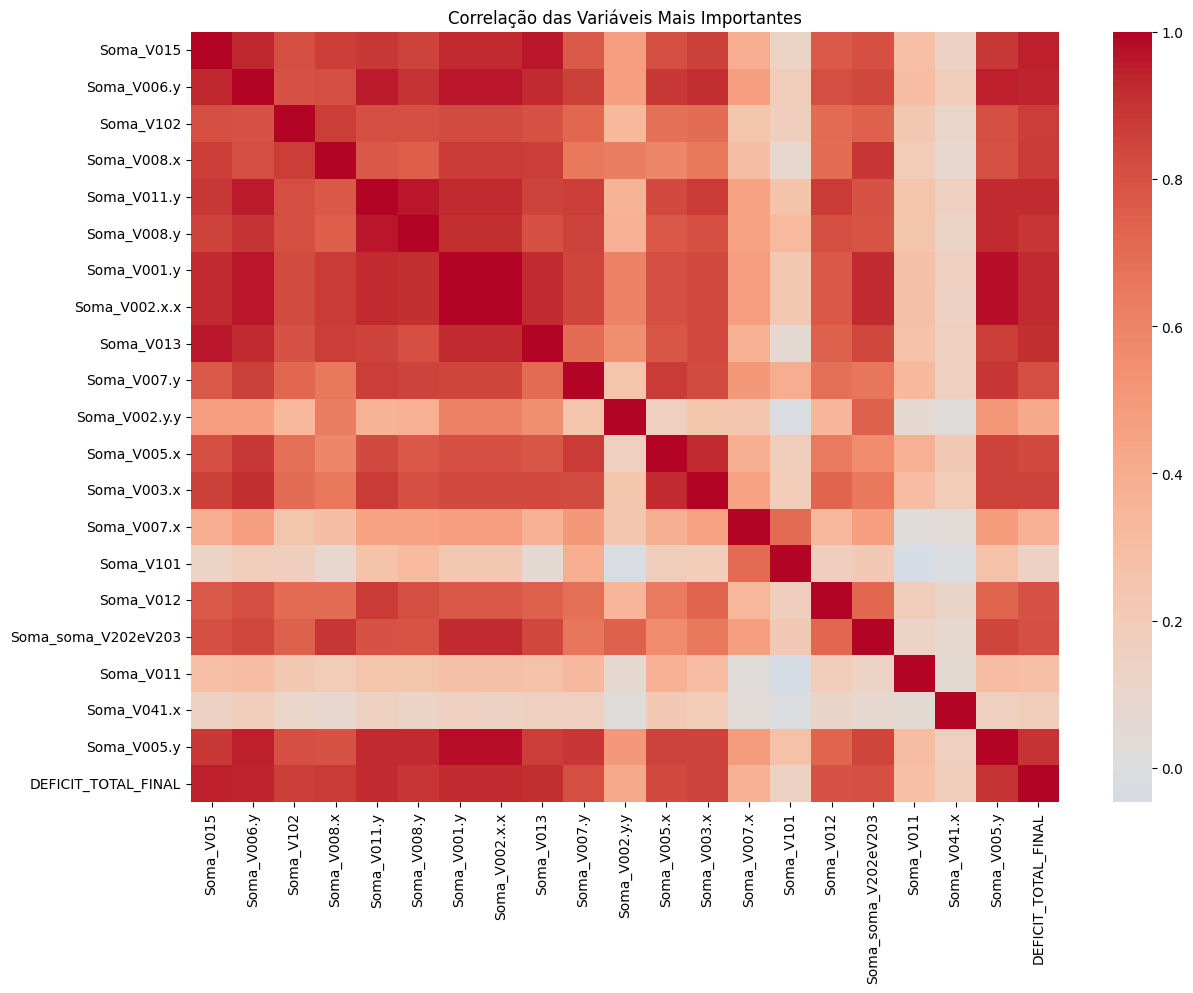

In [26]:
# =====================================================
# MATRIZ DE CORRELAÇÃO
# =====================================================
import seaborn as sns
import matplotlib.pyplot as plt
top_vars = perm_df.head(20)["Variavel"].tolist()

corr = df_sp_ap[
    top_vars + ["DEFICIT_TOTAL_FINAL"]
].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlação das Variáveis Mais Importantes")


# Salvar em JPG
plt.savefig(
    "matriz_correlacao.jpg",
    dpi=300,              # qualidade da imagem
    bbox_inches="tight"   # evita cortes nas bordas
)

plt.show()

## **Junção com a malha geográfica dos setores censitários**

Para as análises espaciais seguintes (Moran, LISA, mapas), precisamos da **geometria** de cada
setor censitário. Ela vem do
shapefile oficial de setores censitários do IBGE (Censo 2022), que esta salvo em formato ( `.zip`) em `data/setores_censitarios/SP_setores_CD2022.zip`.


In [27]:
import geopandas as gpd

gdf = gpd.read_file(
    "SP_setores_CD2022.zip"
)
print(gdf.head())

          CD_SETOR SITUACAO CD_SIT CD_TIPO  AREA_KM2 CD_REGIAO NM_REGIAO  \
0  350010505000001   Urbana      1       0  0.123824         3   Sudeste   
1  350010505000002   Urbana      1       0  0.202614         3   Sudeste   
2  350010505000003   Urbana      1       0  0.235048         3   Sudeste   
3  350010505000004   Urbana      1       0  0.288468         3   Sudeste   
4  350010505000005   Urbana      1       0  0.213724         3   Sudeste   

  CD_UF      NM_UF   CD_MUN  ... NM_FCU CD_AGLOM NM_AGLOM CD_RGINT  \
0    35  São Paulo  3500105  ...   None     None     None     3505   
1    35  São Paulo  3500105  ...   None     None     None     3505   
2    35  São Paulo  3500105  ...   None     None     None     3505   
3    35  São Paulo  3500105  ...   None     None     None     3505   
4    35  São Paulo  3500105  ...   None     None     None     3505   

              NM_RGINT  CD_RGI                NM_RGI CD_CONCURB NM_CONCURB  \
0  Presidente Prudente  350019  Adamantina -

In [28]:
print(df_resultado.columns)

Index(['COD_SC', 'COD_AP', 'DEFICIT_TOTAL_PROPENSO', 'PESO', 'FONTE_VALOR_AP',
       'RESIDUO_AP'],
      dtype='object')


In [29]:
# =====================================================
# JUNÇÃO DOS RESULTADOS COM A MALHA DOS SETORES
# =====================================================

gdf["CD_SETOR"] = gdf["CD_SETOR"].astype(str)
df_resultado["COD_SC"] = df_resultado["COD_SC"].astype(str)

gdf_deficit = gdf.merge(
    df_resultado,
    left_on="CD_SETOR",
    right_on="COD_SC",
    how="inner"
)

print("Setores com geometria:", len(gdf_deficit))

Setores com geometria: 38234


In [30]:
!pip install esda libpysal

## **Autocorrelação espacial — Índice de Moran Global**

Com as estimativas de déficit já em nível de setor censitário, resta uma pergunta importante:
**a distribuição espacial resultante faz sentido geograficamente**, ou é apenas ruído estatístico
introduzido pelo processo de desagregação? Para responder, usamos o **Índice de Moran Global**,
que testa se setores vizinhos tendem a ter valores parecidos (autocorrelação espacial positiva),
valores muito diferentes (autocorrelação negativa) ou se a distribuição é essencialmente
aleatória no espaço (ausência de autocorrelação).

A vizinhança é definida por **KNN (K-Nearest Neighbors)**, com k = 8: cada setor é conectado aos
8 setores geograficamente mais próximos (por centróide), o que evita distorções causadas pela
grande variação de tamanho/forma dos setores censitários (do centro denso da capital às zonas
rurais do interior). A significância estatística é avaliada por 999 permutações aleatórias.

> Se você não tem familiaridade com o Índice de Moran ou LISA, veja a explicação conceitual em
> [`01_conceitos_teoricos.ipynb`](01_conceitos_teoricos.ipynb).


In [31]:
# =================
# MORAN GLOBAL
# =================

import pandas as pd
from IPython.display import display
from libpysal.weights import KNN
from esda.moran import Moran

# K = 8 vizinhos
w = KNN.from_dataframe(
    gdf_deficit,
    k=8
)

w.transform = "R"

# Cálculo do Moran Global
mi = Moran(
    gdf_deficit["DEFICIT_TOTAL_PROPENSO"],
    w,
    permutations=999
)

# ==========================
# Tabela de resultados
# ==========================

resultado_moran = pd.DataFrame({
    "Estatística": [
        "Moran I",
        "p-valor",
        "Número de permutações",
        "Tipo de vizinhança"
    ],
    "Resultado": [
        round(mi.I, 6),
        round(mi.p_sim, 6),
        999,
        "KNN (k=8)"
    ]
})

display(resultado_moran)

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 115 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


,Estatística,Resultado
0,Moran I,0.524625
1,p-valor,0.001
2,Número de permutações,999
3,Tipo de vizinhança,KNN (k=8)


## Interpretação — Moran Global

**I = 0,524625, p = 0,001.**

O valor positivo e estatisticamente significativo (p < 0,05, com folga considerável) indica
**autocorrelação espacial positiva**: setores com déficit elevado tendem a estar cercados por
outros setores também com déficit elevado, e o mesmo vale para os setores com déficit baixo. Um
Moran I próximo de 0,52 é um valor relativamente alto para fenômenos socioespaciais complexos, e
é uma evidência importante de que **o processo de desagregação não introduziu ruído espacial
aleatório** — se tivesse, o índice estaria próximo de zero. A estrutura territorial observada é
coerente com o que se espera do fenômeno (concentração de vulnerabilidade habitacional em
regiões contíguas, refletindo padrões históricos de segregação socioespacial).


## **Autocorrelação espacial local — LISA (Local Indicators of Spatial Association)**

O Moran Global responde "existe estrutura espacial no estado como um todo?". Para saber **onde**
essa estrutura ocorre, usamos os **Indicadores Locais de Associação Espacial (LISA)**, que
classificam cada setor segundo sua relação com a vizinhança:

- **HH (Alto-Alto):** setor com déficit alto, cercado por vizinhos também com déficit alto —
  núcleo de vulnerabilidade concentrada;
- **LL (Baixo-Baixo):** setor com déficit baixo, cercado por vizinhos também com déficit baixo —
  região relativamente mais favorecida;
- **HL / LH:** setor destoante da vizinhança (contraste local, possível zona de transição).


In [32]:
# =====================================================
# LISA (LOCAL MORAN)
# =====================================================

import pandas as pd
from IPython.display import display
from esda.moran import Moran_Local

lisa = Moran_Local(
    gdf_deficit["DEFICIT_TOTAL_PROPENSO"],
    w,
    permutations=999
)

gdf_deficit["LISA_P"] = lisa.p_sim
gdf_deficit["LISA_Q"] = lisa.q

gdf_deficit["SIGNIFICATIVO"] = (
    gdf_deficit["LISA_P"] < 0.05
)

display(
    gdf_deficit[
        ["LISA_Q", "SIGNIFICATIVO"]
    ].head()
)

,LISA_Q,SIGNIFICATIVO
0,3,True
1,3,True
2,3,False
3,4,False
4,4,False


## **Classificação dos clusters (HH / LL / HL / LH)**

In [33]:
# =====================================================
# CLASSIFICAÇÃO LISA
# =====================================================

import pandas as pd
from IPython.display import display

def classifica_lisa(row):

    if not row["SIGNIFICATIVO"]:
        return "Nao significativo"

    if row["LISA_Q"] == 1:
        return "HH"

    elif row["LISA_Q"] == 2:
        return "LH"

    elif row["LISA_Q"] == 3:
        return "LL"

    elif row["LISA_Q"] == 4:
        return "HL"

    return "Nao significativo"


gdf_deficit["CLUSTER"] = (
    gdf_deficit.apply(
        classifica_lisa,
        axis=1
    )
)

# =====================================================
# Tabela de resultados
# =====================================================

resultado_clusters = (
    gdf_deficit["CLUSTER"]
    .value_counts()
    .reset_index()
)

resultado_clusters.columns = [
    "Cluster LISA",
    "Quantidade"
]

display(resultado_clusters)

,Cluster LISA,Quantidade
0,Nao significativo,21698
1,LL,8537
2,HH,6240
3,LH,1416
4,HL,343


# **MAPA LISA**

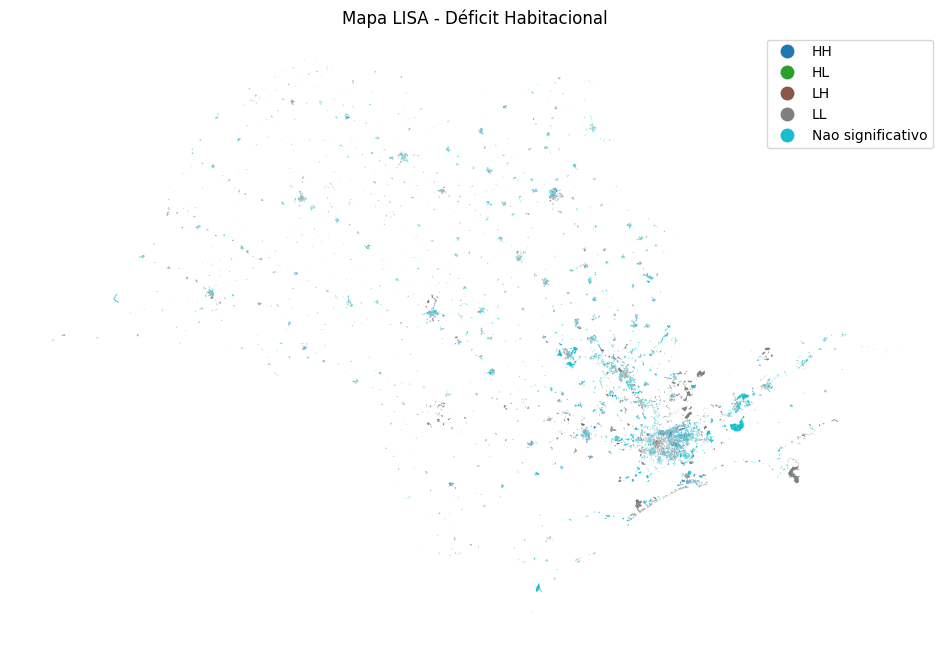

In [34]:
# =====================================================
# MAPA LISA
# =====================================================

fig, ax = plt.subplots(
    figsize=(12,12)
)

gdf_deficit.plot(
    column="CLUSTER",
    legend=True,
    ax=ax
)

plt.title(
    "Mapa LISA - Déficit Habitacional"
)

plt.axis("off")


# Salvar em JPG
plt.savefig(
    "Mapa_LISA.jpg",
    dpi=300,              # qualidade da imagem
    bbox_inches="tight"   # evita cortes nas bordas
)

plt.show()

## **Moran Scatter Plot**

Complementa a leitura do Índice de Moran Global: no eixo horizontal está o valor padronizado do
déficit em cada setor; no eixo vertical, a média (padronizada) dos valores dos setores vizinhos
(*lag* espacial). A inclinação da reta ajustada corresponde ao próprio Índice de Moran Global.


In [35]:
!pip install splot

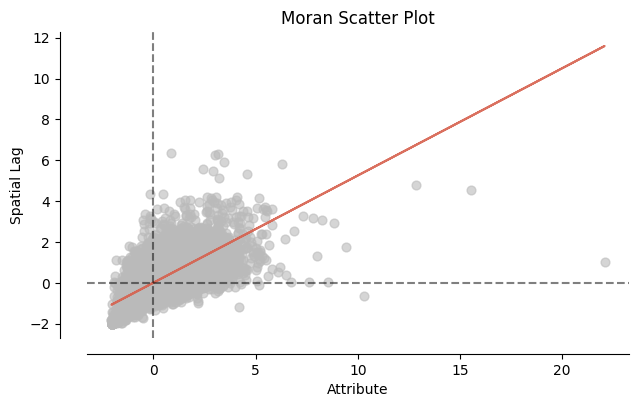

In [36]:
from esda.moran import Moran
from splot.esda import moran_scatterplot

fig, ax = moran_scatterplot(mi)

plt.title(
    "Moran Scatter Plot"
)

plt.show()

# **Mapa do déficit habitacional desagregado**

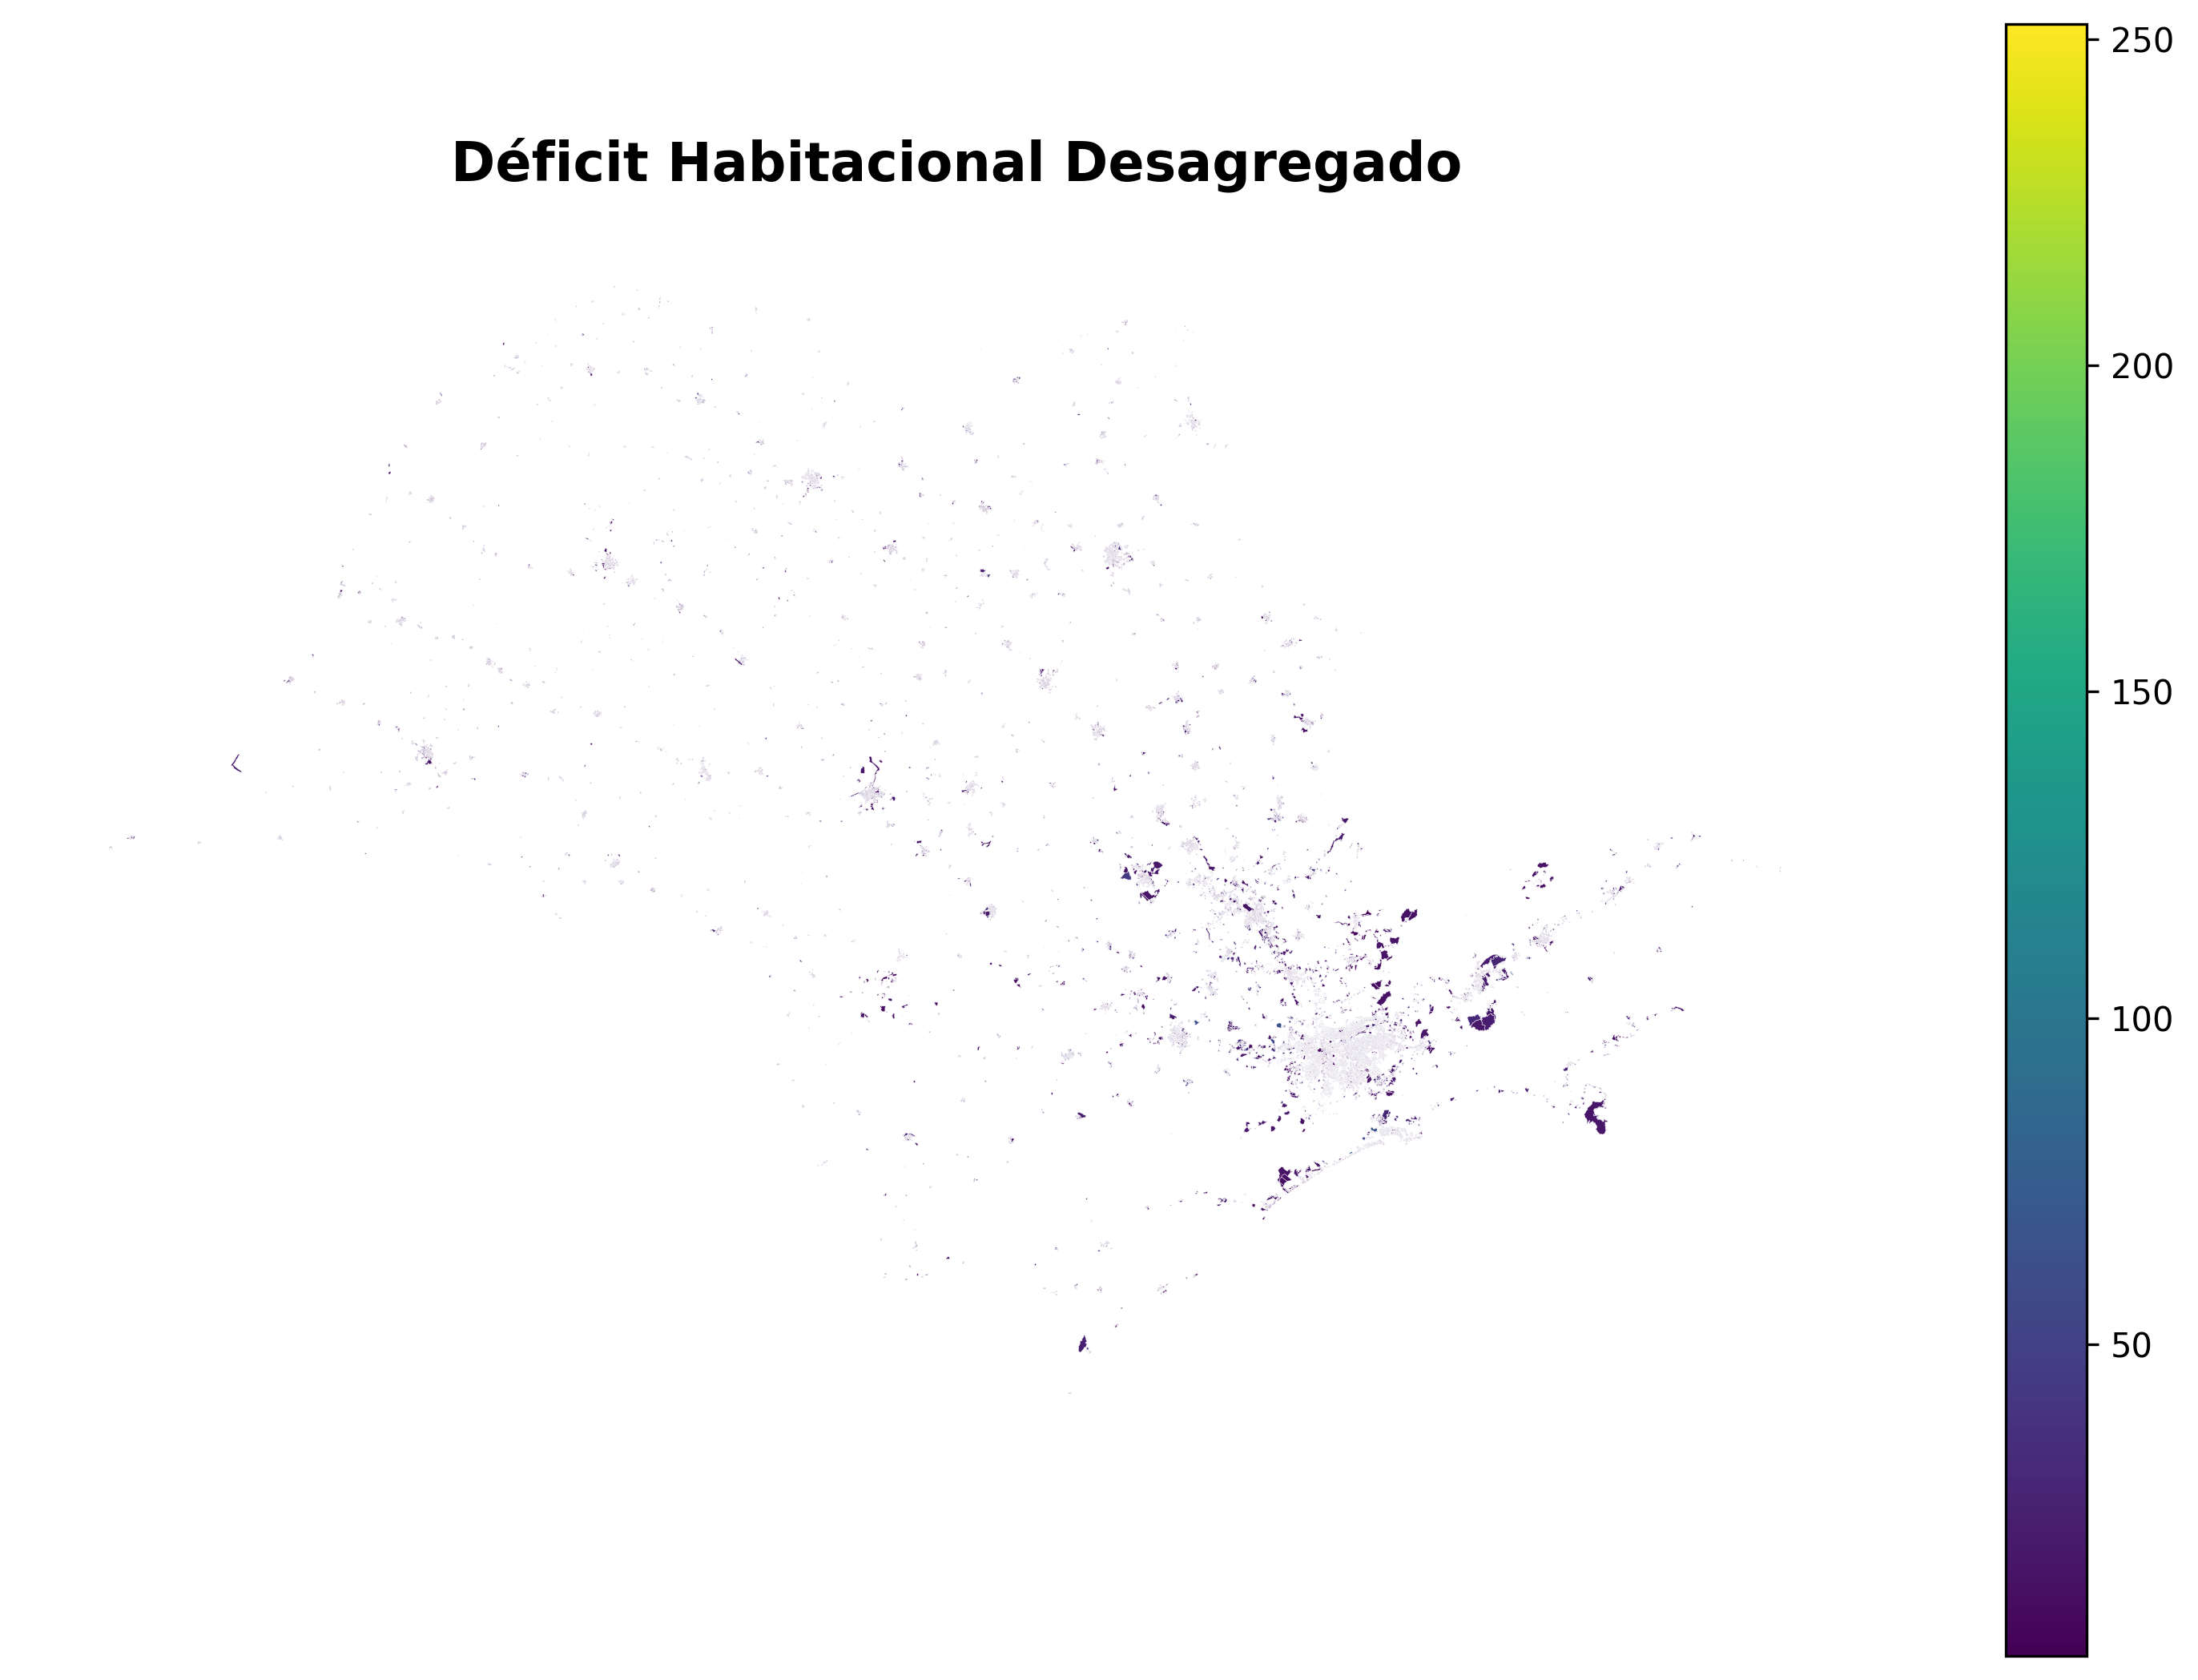

In [37]:
# =====================================================
# MAPA DO DÉFICIT
# =====================================================

fig, ax = plt.subplots(
    figsize=(10, 10),
    dpi=300
)

gdf_deficit.plot(
    column="DEFICIT_TOTAL_PROPENSO",
    cmap="viridis",      # ou YlOrRd se preferir
    legend=True,
    linewidth=0.1,
    edgecolor="white",
    ax=ax,
    legend_kwds={
        "shrink": 0.7
    }
)

ax.set_title(
    "Déficit Habitacional Desagregado",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.axis("off")

plt.tight_layout()

# Salvar em JPG
plt.savefig(
    "Deficit_Habitacional_Desagregado.jpg",
    dpi=300,              # qualidade da imagem
    bbox_inches="tight"   # evita cortes nas bordas
)


plt.show()